# Feature Scaling - Standardization using Wine Dataset

## Import Libraries

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load The Dataset

In [105]:
## Load the Dataset

from sklearn.datasets import load_wine

wine=load_wine(as_frame=True)

#features
X = wine.data

#target
y = wine.target

#complete dataframe
df=wine.frame

## Exploratory Data Analysis

In [106]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


## Train test split

In [107]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train, y_test = train_test_split(df.drop('target',axis=1),
                                                     df['target'],
                                                     test_size=0.3,
                                                     random_state=0)

In [108]:
X_train.shape, X_test.shape

((124, 13), (54, 13))

## Standard Scaler

In [109]:
from sklearn.preprocessing import StandardScaler

scaler =  StandardScaler()

# Fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# Transform Train and Test set
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [110]:
scaler.mean_

array([1.29830645e+01, 2.38370968e+00, 2.36314516e+00, 1.95258065e+01,
       1.00088710e+02, 2.25838710e+00, 1.96951613e+00, 3.64274194e-01,
       1.61250000e+00, 4.99991935e+00, 9.55854839e-01, 2.60193548e+00,
       7.46766129e+02])

In [111]:
X_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
22,13.71,1.86,2.36,16.6,101.0,2.61,2.88,0.27,1.69,3.80,1.11,4.00,1035.0
108,12.22,1.29,1.94,19.0,92.0,2.36,2.04,0.39,2.08,2.70,0.86,3.02,312.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
145,13.16,3.57,2.15,21.0,102.0,1.50,0.55,0.43,1.30,4.00,0.60,1.68,830.0
71,13.86,1.51,2.67,25.0,86.0,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,11.82,1.72,1.88,19.5,86.0,2.50,1.64,0.37,1.42,2.06,0.94,2.44,415.0
67,12.37,1.17,1.92,19.6,78.0,2.11,2.00,0.27,1.04,4.68,1.12,3.48,510.0
117,12.42,1.61,2.19,22.5,108.0,2.00,2.09,0.34,1.61,2.06,1.06,2.96,345.0
47,13.90,1.68,2.12,16.0,101.0,3.10,3.39,0.21,2.14,6.10,0.91,3.33,985.0


In [112]:
X_train_scaled

array([[ 0.91083058, -0.46259897, -0.01142613, ...,  0.65706596,
         1.94354495,  0.93700997],
       [-0.95609928, -0.96608672, -1.53725357, ..., -0.40859506,
         0.58118003, -1.41336684],
       [ 0.35952243,  1.67501572, -0.37471838, ..., -1.55950896,
        -1.44846566,  0.28683658],
       ...,
       [-0.70550467, -0.68342693, -0.62902295, ...,  0.44393375,
         0.49776993, -1.30608823],
       [ 1.14889546, -0.6215951 , -0.88332752, ..., -0.19546286,
         1.0121322 ,  0.77446662],
       [ 1.47466845,  0.11155374,  0.42452457, ..., -1.43162964,
        -1.23994042, -0.28206514]], shape=(124, 13))

In [113]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [114]:
np.round(X_train.describe() , 1)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0
mean,13.0,2.4,2.4,19.5,100.1,2.3,2.0,0.4,1.6,5.0,1.0,2.6,746.8
std,0.8,1.1,0.3,3.6,14.7,0.6,1.0,0.1,0.6,2.4,0.2,0.7,308.9
min,11.0,0.9,1.4,10.6,70.0,1.1,0.5,0.1,0.4,1.3,0.5,1.3,312.0
25%,12.4,1.6,2.2,17.1,89.0,1.7,1.1,0.3,1.2,3.0,0.8,1.9,510.0
50%,13.0,1.9,2.4,19.4,98.0,2.2,2.1,0.3,1.6,4.6,1.0,2.8,667.5
75%,13.6,3.2,2.6,21.7,106.2,2.7,2.8,0.4,2.0,6.4,1.1,3.2,986.2
max,14.8,5.6,3.2,30.0,162.0,3.9,3.7,0.7,3.6,11.8,1.7,4.0,1547.0


In [115]:
np.round(X_train_scaled.describe() , 1)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0
mean,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,-2.4,-1.3,-3.6,-2.5,-2.1,-1.9,-1.5,-1.8,-2.0,-1.6,-1.8,-1.9,-1.4
25%,-0.8,-0.7,-0.5,-0.7,-0.8,-0.9,-0.9,-0.8,-0.6,-0.8,-0.7,-1.0,-0.8
50%,0.1,-0.4,-0.0,-0.0,-0.1,-0.1,0.1,-0.2,-0.1,-0.2,0.0,0.2,-0.3
75%,0.8,0.8,0.7,0.6,0.4,0.7,0.8,0.7,0.6,0.6,0.7,0.8,0.8
max,2.2,2.9,3.1,2.9,4.2,2.7,1.8,2.4,3.3,2.9,3.2,1.9,2.6


# Effect of Scaling

## Scatter Plot

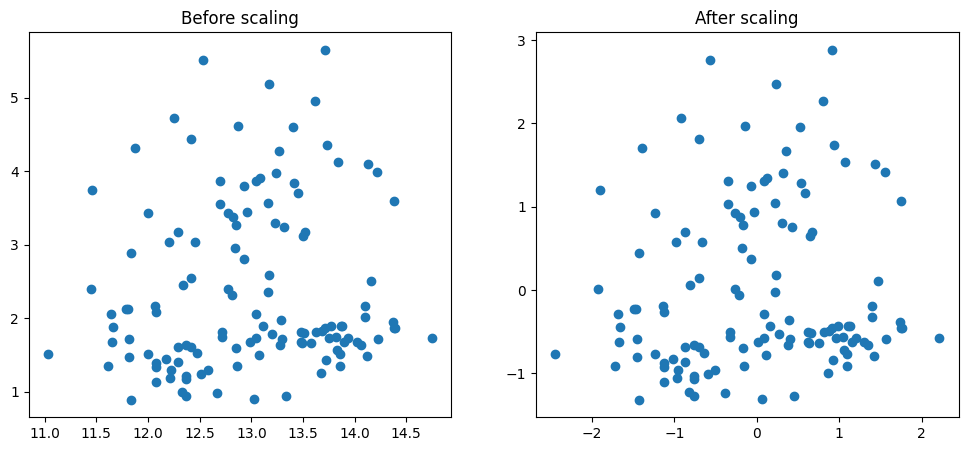

In [116]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize=(12,5))

ax1.scatter(X_train['alcohol'], X_train['malic_acid'])
ax1.set_title('Before scaling')

ax2.scatter(X_train_scaled['alcohol'], X_train_scaled['malic_acid'])
ax2.set_title('After scaling')

plt.show()


## kdeplot

[]

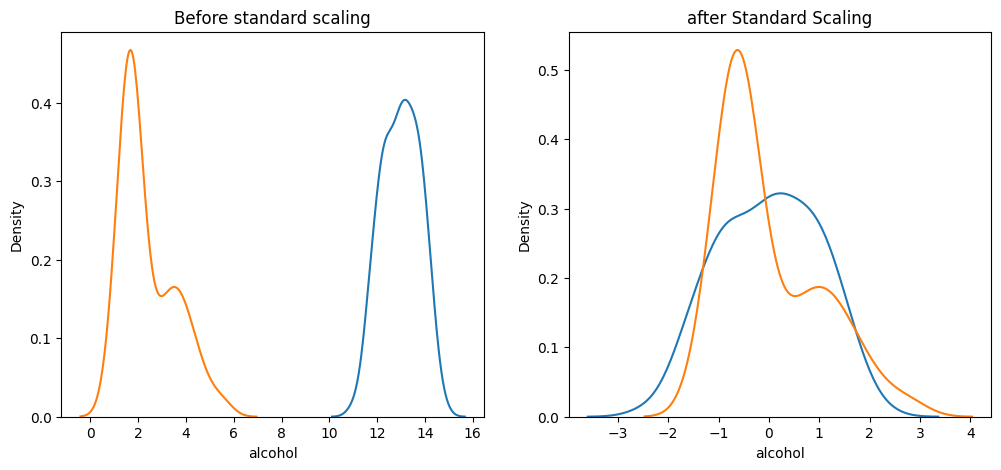

In [117]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before scaling
ax1.set_title('Before standard scaling')
sns.kdeplot(X_train['alcohol'], ax=ax1)
sns.kdeplot(X_train['malic_acid'], ax=ax1)

# after scaling
ax2.set_title('after Standard Scaling')
sns.kdeplot(X_train_scaled['alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['malic_acid'], ax=ax2)
plt.plot()


# Comparision of Distribution

[]

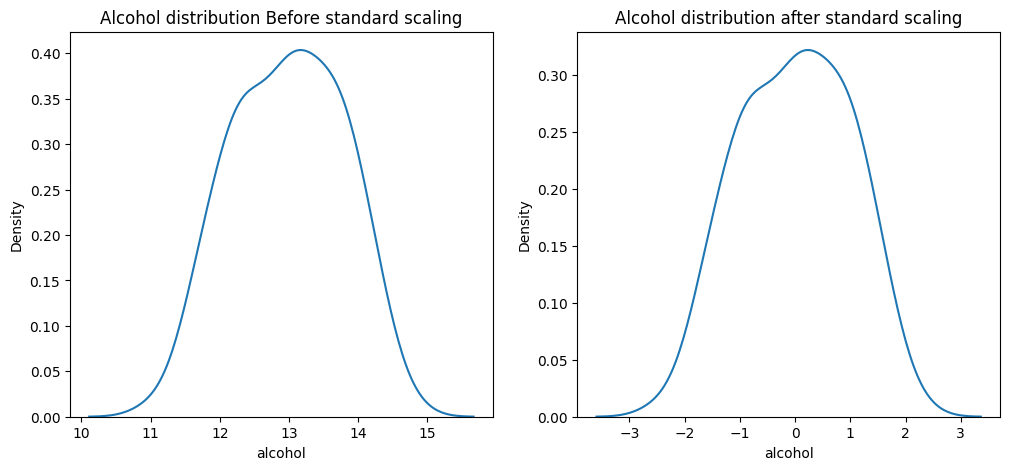

In [118]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before scaling
ax1.set_title('Alcohol distribution Before standard scaling')
sns.kdeplot(X_train['alcohol'], ax=ax1)

# After scaling
ax2.set_title('Alcohol distribution after standard scaling')
sns.kdeplot(X_train_scaled['alcohol'], ax=ax2)

plt.plot()

[]

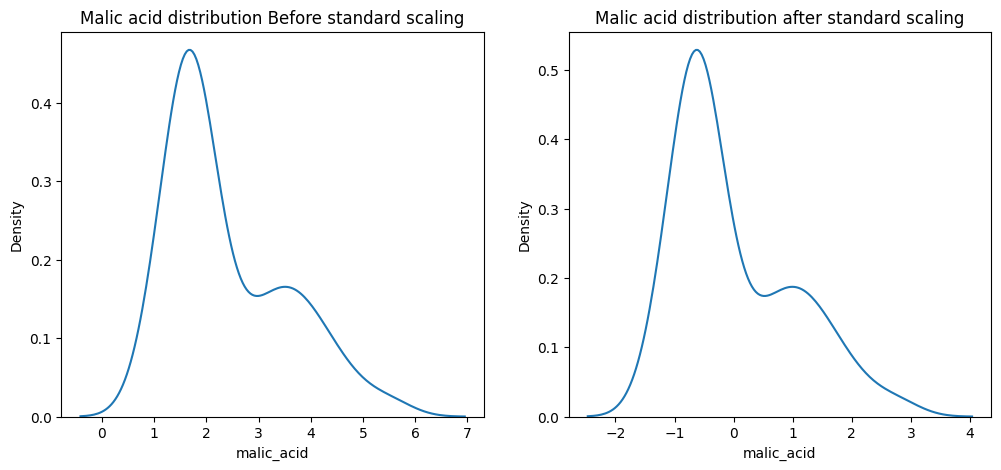

In [119]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before scaling
ax1.set_title('Malic acid distribution Before standard scaling')
sns.kdeplot(X_train['malic_acid'], ax=ax1)

# After scaling
ax2.set_title('Malic acid distribution after standard scaling')
sns.kdeplot(X_train_scaled['malic_acid'], ax=ax2)

plt.plot()

# Why scaling is important ?

In [120]:
from sklearn.linear_model import LogisticRegression

In [121]:
ir = LogisticRegression(max_iter=500)


In [122]:
ir_scaled = LogisticRegression(max_iter=500)

In [125]:
ir.fit(X_train,y_train)
ir_scaled.fit(X_train_scaled,y_train)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [126]:
y_pred=ir.predict(X_test)
y_pred_scaled=ir_scaled.predict(X_test_scaled)

In [127]:

from sklearn.metrics import accuracy_score


In [128]:
print("actual", accuracy_score(y_test,y_pred))
print("scaled", accuracy_score(y_test,y_pred_scaled))

actual 0.9259259259259259
scaled 1.0


# Effect of scaling in decision tree

In [71]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [72]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [73]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.9444444444444444
Scaled 0.9444444444444444


# Effect of Outlier

In [129]:
outliers=pd.DataFrame({'alcohol':[30,35,40],
                       'malic_acid':[10,12,15]})
df = pd.concat([df, outliers], ignore_index=True)

In [130]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2.0
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.20,0.61,1.60,560.0,2.0
178,30.00,10.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179,35.00,12.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


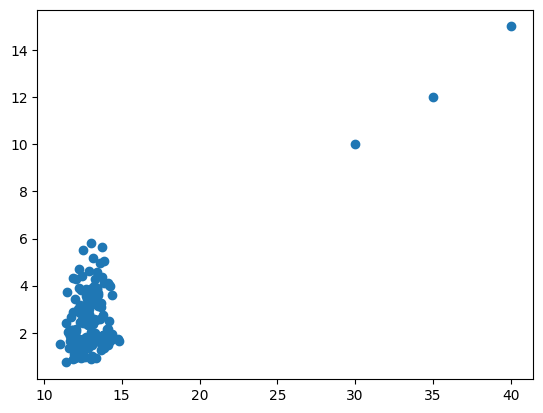

In [131]:
plt.scatter(df['alcohol'], df['malic_acid'])


In [132]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1),
                                                    df['target'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape


((126, 13), (55, 13))

In [133]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [134]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


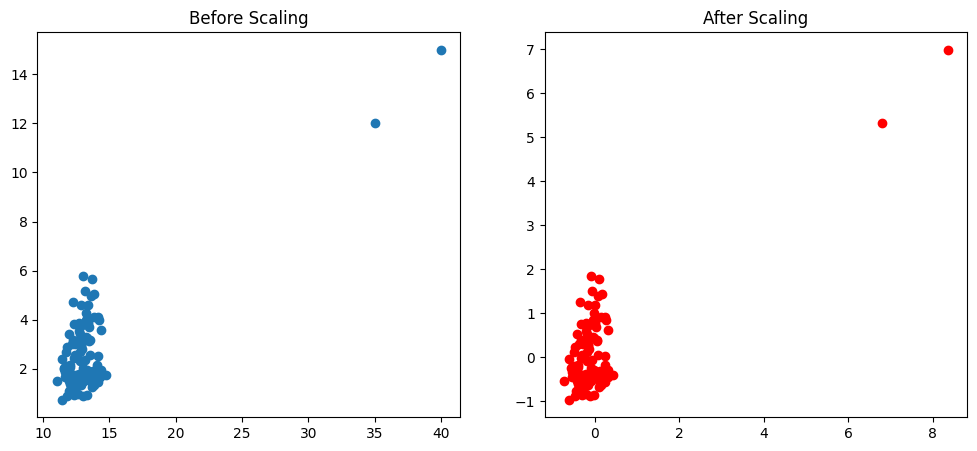

In [135]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['alcohol'], X_train['malic_acid'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['alcohol'], X_train_scaled['malic_acid'],color='red')
ax2.set_title("After Scaling")
plt.show()

## Conclution of outlier
### Feature scaling does not remove outliers. since standard scaler uses mean and standard deviation , extreme values change both of them. Therefore, the influence of outliers reamins even after scaling.